In [1]:
pip install numpy pandas matplotlib tabulate

Note: you may need to restart the kernel to use updated packages.


   Underlying Price  Straddle Profit  Futures Profit  Total Profit  \
0         97.309143         0.000000        0.000000      0.000000   
1         97.886793         2.113207       -0.577650      1.535557   
2         95.399860         4.600140        2.486933      7.087073   
3         95.584120         4.415880       -0.184260      4.231619   
4         95.207605         4.792395        0.376515      5.168911   

   Total Profit with Starting Capital  
0                          100.000000  
1                          101.535557  
2                          107.087073  
3                          104.231619  
4                          105.168911  


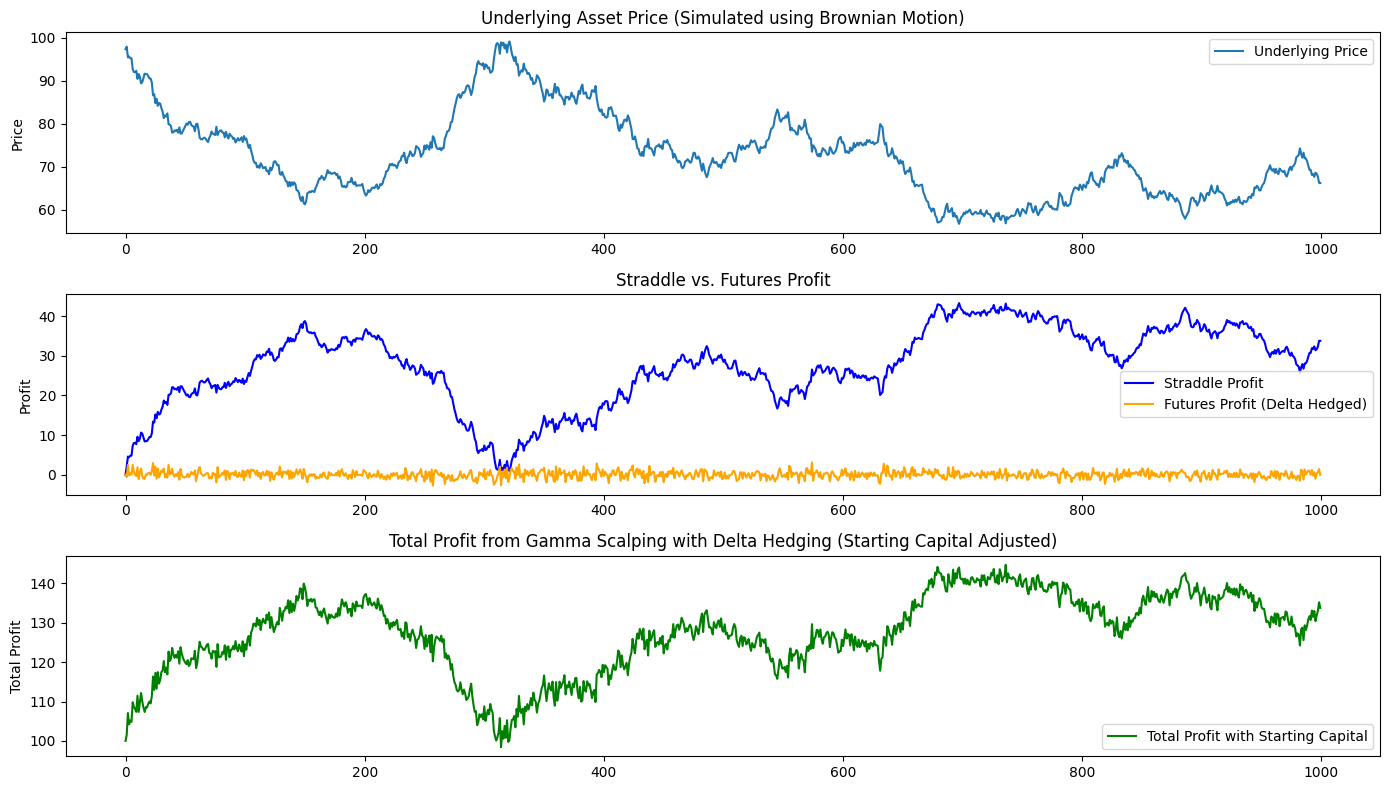

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

# Parameters
NP_SEED = 69420
np.random.seed(NP_SEED)
n_steps = 1000  # number of time steps
dt = 1/252  # time step size (in years, assuming 252 trading days in a year)
mu = 0  # drift
sigma = 0.2  # volatility (annualized)
S0 = 100  # initial price
K = 100  # strike price (ATM options)
T = 30/252  # time to expiry (30 days)
r = 0.01  # risk-free rate
futures_multiplier = 1  # multiplier for futures contracts
starting_capital = 100  # define starting capital

# Simulate underlying price using Geometric Brownian Motion
t = np.linspace(0, T, n_steps)
S = S0 * np.exp((mu - 0.5 * sigma ** 2) * t + sigma * np.sqrt(dt) * np.random.randn(n_steps).cumsum())

# Add a small epsilon to avoid division by zero when T is very small
epsilon = 1e-6

# Functions to calculate options Greeks
def delta_call(S, K, T, r, sigma):
    from scipy.stats import norm
    T = max(T, epsilon)  # Avoid division by zero
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def delta_put(S, K, T, r, sigma):
    from scipy.stats import norm
    T = max(T, epsilon)  # Avoid division by zero
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1) - 1

def straddle_delta(S, K, T, r, sigma):
    return delta_call(S, K, T, r, sigma) - delta_put(S, K, T, r, sigma)

# Initialize variables
futures_position = 0
straddle_profit = np.zeros(n_steps)
futures_profit = np.zeros(n_steps)
total_profit = np.zeros(n_steps)

# Simulate Gamma Scalping and Delta Hedging
for i in range(1, n_steps):
    t_remaining = T - t[i]
    straddle_d = straddle_delta(S[i], K, t_remaining, r, sigma)
    
    # Update the futures position to delta hedge
    futures_position = -straddle_d
    
    # Calculate profits from options and futures position
    straddle_profit[i] = max(S[i] - K, 0) + max(K - S[i], 0)
    futures_profit[i] = futures_position * (S[i] - S[i-1])
    total_profit[i] = straddle_profit[i] + futures_profit[i]

# Adjust total profit with starting capital
total_profit_with_capital = total_profit + starting_capital

# Create a DataFrame for visualization
df = pd.DataFrame({
    'Underlying Price': S,
    'Straddle Profit': straddle_profit,
    'Futures Profit': futures_profit,
    'Total Profit': total_profit,
    'Total Profit with Starting Capital': total_profit_with_capital
})

# Display the DataFrame as output
print(df.head())  # This prints the first few rows of the DataFrame

# Plot the results
plt.figure(figsize=(14, 8))

# Underlying Price
plt.subplot(3, 1, 1)
plt.plot(df['Underlying Price'], label='Underlying Price')
plt.title('Underlying Asset Price (Simulated using Brownian Motion)')
plt.ylabel('Price')
plt.legend()

# Straddle and Futures Profit
plt.subplot(3, 1, 2)
plt.plot(df['Straddle Profit'], label='Straddle Profit', color='blue')
plt.plot(df['Futures Profit'], label='Futures Profit (Delta Hedged)', color='orange')
plt.title('Straddle vs. Futures Profit')
plt.ylabel('Profit')
plt.legend()

# Total Profit with Starting Capital
plt.subplot(3, 1, 3)
plt.plot(df['Total Profit with Starting Capital'], label='Total Profit with Starting Capital', color='green')
plt.title('Total Profit from Gamma Scalping with Delta Hedging (Starting Capital Adjusted)')
plt.ylabel('Total Profit')
plt.legend()

plt.tight_layout()
plt.show()

# Save to CSV
df.to_csv('gamma_scalping_delta_hedging_simulation_with_capital.csv', index=False)

   Underlying Price  Straddle Profit  Futures Profit  Total Fees  \
0         97.309143         0.000000        0.000000    0.000000   
1         97.886793         2.113207       -0.577650    0.029789   
2         95.399860         4.600140        2.486933    0.058160   
3         95.584120         4.415880       -0.184260    0.058234   
4         95.207605         4.792395        0.376515    0.058083   

   Total Profit  Total Profit with Starting Capital  
0      0.000000                          100.000000  
1      1.505768                          101.505768  
2      7.028913                          107.028913  
3      4.173386                          104.173386  
4      5.110827                          105.110827  


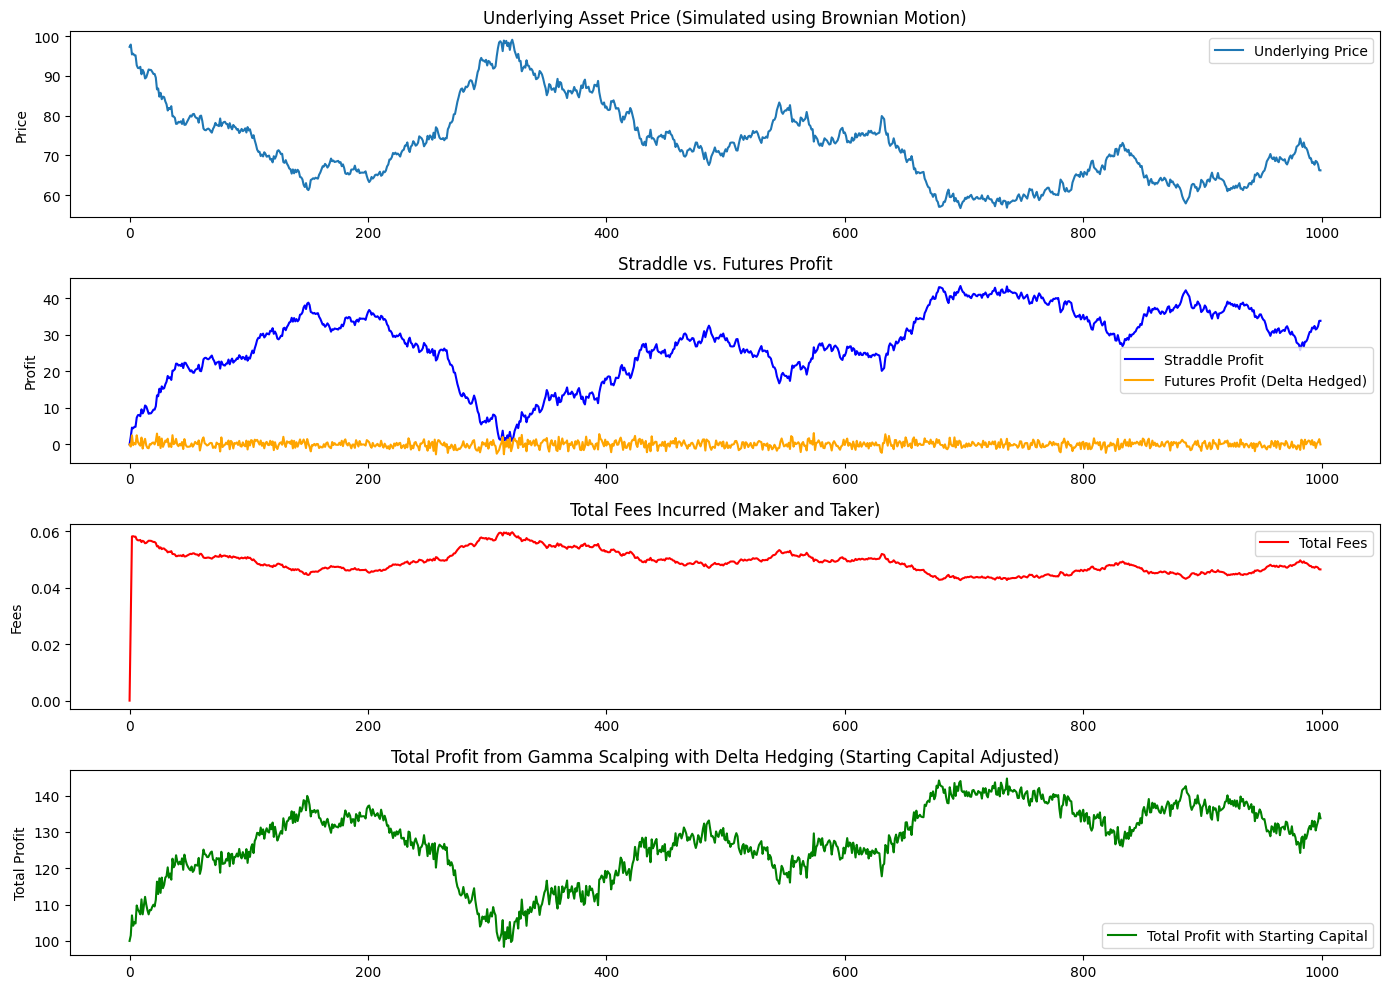

In [3]:
# Trading fees
maker_fee = 0.020 / 100  # 0.020% maker fee
taker_fee = 0.030 / 100  # 0.030% taker fee

# Initialize variables
futures_position = 0
straddle_profit = np.zeros(n_steps)
futures_profit = np.zeros(n_steps)
total_profit = np.zeros(n_steps)
fee_costs = np.zeros(n_steps)

# Simulate Gamma Scalping and Delta Hedging with Fees
for i in range(1, n_steps):
    t_remaining = T - t[i]
    straddle_d = straddle_delta(S[i], K, t_remaining, r, sigma)
    
    # Update the futures position to delta hedge
    futures_trade_size = abs(straddle_d - futures_position)  # Size of the futures trade
    futures_position = -straddle_d
    
    # Calculate profits from options and futures position
    straddle_profit[i] = max(S[i] - K, 0) + max(K - S[i], 0)
    futures_profit[i] = futures_position * (S[i] - S[i-1])
    
    # Trading fees
    futures_fee = futures_trade_size * S[i] * taker_fee  # Fee for delta hedging (taker)
    option_fee = straddle_profit[i] * maker_fee  # Fee for option transactions (maker)
    
    # Track total fees
    fee_costs[i] = futures_fee + option_fee
    
    # Total profit includes fees
    total_profit[i] = straddle_profit[i] + futures_profit[i] - fee_costs[i]

# Adjust total profit with starting capital
total_profit_with_capital = total_profit + starting_capital

# Create a DataFrame for visualization including fees
df_with_fees = pd.DataFrame({
    'Underlying Price': S,
    'Straddle Profit': straddle_profit,
    'Futures Profit': futures_profit,
    'Total Fees': fee_costs,
    'Total Profit': total_profit,
    'Total Profit with Starting Capital': total_profit_with_capital
})

# Display the DataFrame as output
print(df_with_fees.head())  # This prints the first few rows of the DataFrame

# Plot the results
plt.figure(figsize=(14, 10))

# Underlying Price
plt.subplot(4, 1, 1)
plt.plot(df_with_fees['Underlying Price'], label='Underlying Price')
plt.title('Underlying Asset Price (Simulated using Brownian Motion)')
plt.ylabel('Price')
plt.legend()

# Straddle and Futures Profit
plt.subplot(4, 1, 2)
plt.plot(df_with_fees['Straddle Profit'], label='Straddle Profit', color='blue')
plt.plot(df_with_fees['Futures Profit'], label='Futures Profit (Delta Hedged)', color='orange')
plt.title('Straddle vs. Futures Profit')
plt.ylabel('Profit')
plt.legend()

# Total Fees
plt.subplot(4, 1, 3)
plt.plot(df_with_fees['Total Fees'], label='Total Fees', color='red')
plt.title('Total Fees Incurred (Maker and Taker)')
plt.ylabel('Fees')
plt.legend()

# Total Profit with Starting Capital
plt.subplot(4, 1, 4)
plt.plot(df_with_fees['Total Profit with Starting Capital'], label='Total Profit with Starting Capital', color='green')
plt.title('Total Profit from Gamma Scalping with Delta Hedging (Starting Capital Adjusted)')
plt.ylabel('Total Profit')
plt.legend()

plt.tight_layout()
plt.show()

# Save to CSV
df_with_fees.to_csv('gamma_scalping_delta_hedging_simulation_with_fees.csv', index=False)


In [4]:
# Create a new DataFrame to include Net Profit, Gross Profit, and Commissions Paid
df_commission_summary = pd.DataFrame({
    'Underlying Price': S,
    'Gross Profit (Straddle + Futures)': straddle_profit + futures_profit,
    'Total Fees': fee_costs,
    'Net Profit (After Fees)': total_profit
})

# Print the first few rows of the DataFrame
print(tabulate(df_commission_summary.head(), headers='keys', tablefmt='pretty', showindex=False))

# Save the DataFrame to a CSV file in the current working directory
df_commission_summary.to_csv('gamma_scalping_commission_summary.csv', index=False)

+-------------------+-----------------------------------+----------------------+-------------------------+
| Underlying Price  | Gross Profit (Straddle + Futures) |      Total Fees      | Net Profit (After Fees) |
+-------------------+-----------------------------------+----------------------+-------------------------+
| 97.30914300077596 |                0.0                |         0.0          |           0.0           |
| 97.88679299020865 |        1.5355570203586666         | 0.029788679299020862 |   1.5057683410596456    |
| 95.3998601921308  |         7.087072605947043         | 0.058159944076852314 |    7.028912661870191    |
| 95.58412038676893 |         4.231619418592942         | 0.05823364815470757  |    4.173385770438235    |
| 95.20760494008935 |        5.1689105065902226         | 0.05808304197603573  |    5.110827464614187    |
+-------------------+-----------------------------------+----------------------+-------------------------+


In [5]:
# Print summary statistics for the DataFrame
summary_stats = df_commission_summary.describe()

summary_stats.to_csv('gamma_scalping_summary.csv')
summary_csv = pd.read_csv('gamma_scalping_summary.csv')

print(tabulate(summary_csv, headers='keys', tablefmt='pretty', showindex=False))

+------------+-------------------+-----------------------------------+--------------------+-------------------------+
| Unnamed: 0 | Underlying Price  | Gross Profit (Straddle + Futures) |     Total Fees     | Net Profit (After Fees) |
+------------+-------------------+-----------------------------------+--------------------+-------------------------+
|   count    |      1000.0       |              1000.0               |       1000.0       |         1000.0          |
|    mean    | 72.65701983807017 |        27.371391741555467         | 0.0489745182401306 |   27.322417223315338    |
|    std     | 9.783837808586735 |         9.846363797107871         | 0.0042296695634489 |    9.850019610676624    |
|    min     | 56.70119686550704 |        -1.575847816916891         |        0.0         |   -1.6354101960495888   |
|    25%     | 65.05431561112027 |         22.16753672266332         | 0.0459861509509839 |   22.116360460103003    |
|    50%     | 71.60250626512479 |         28.3311715286

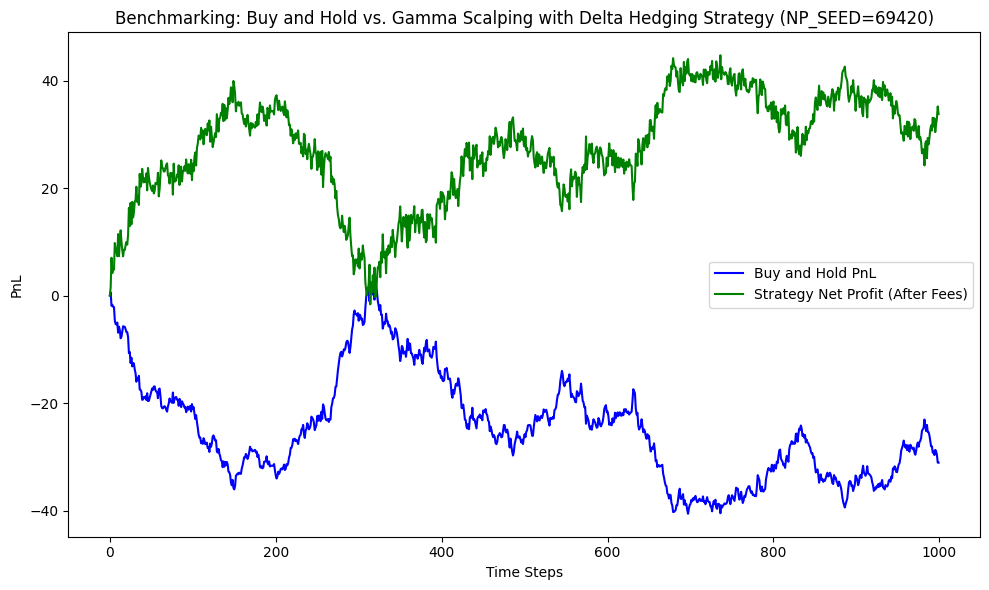

     Underlying Price  Gross Profit (Straddle + Futures)  Total Fees  \
0           97.309143                           0.000000    0.000000   
1           97.886793                           1.535557    0.029789   
2           95.399860                           7.087073    0.058160   
3           95.584120                           4.231619    0.058234   
4           95.207605                           5.168911    0.058083   
..                ...                                ...         ...   
995         68.587933                          30.450729    0.047435   
996         68.348320                          31.891294    0.047339   
997         67.672696                          33.002928    0.047069   
998         66.222848                          35.227001    0.046489   
999         66.206706                          33.809435    0.046483   

     Net Profit (After Fees)  Buy and Hold PnL  
0                   0.000000          0.000000  
1                   1.505768         

In [6]:
# Create a new column in df_commission_summary for buy-and-hold strategy PnL
# Buy-and-hold assumes the trader simply buys the underlying asset at the start and holds it until the end

buy_and_hold_pnl = S - S[0]  # The PnL for buy-and-hold is the change in price from the starting point

# Add this to the DataFrame for comparison
df_commission_summary['Buy and Hold PnL'] = buy_and_hold_pnl

# Plotting the comparison between buy and hold vs strategy (Net Profit After Fees)
plt.figure(figsize=(10, 6))

plt.plot(df_commission_summary['Buy and Hold PnL'], label='Buy and Hold PnL', color='blue')
plt.plot(df_commission_summary['Net Profit (After Fees)'], label='Strategy Net Profit (After Fees)', color='green')
plt.title(f'Benchmarking: Buy and Hold vs. Gamma Scalping with Delta Hedging Strategy ({NP_SEED=})')
plt.xlabel('Time Steps')
plt.ylabel('PnL')
plt.legend()

plt.tight_layout()
plt.show()

print(df_commission_summary)


   Underlying Price  Call Premium  Put Premium    Max Loss  Breakeven Up  \
0         97.309143      1.619351     4.191231  581.058233    105.810582   
1         97.886793      1.838603     3.832952  567.155495    105.671555   
2         95.399860      1.017911     5.499312  651.722213    106.517222   
3         95.584120      1.066253     5.363512  642.976499    106.429765   
4         95.207605      0.965924     5.639818  660.574248    106.605742   

   Breakeven Down  
0       94.189418  
1       94.328445  
2       93.482778  
3       93.570235  
4       93.394258  


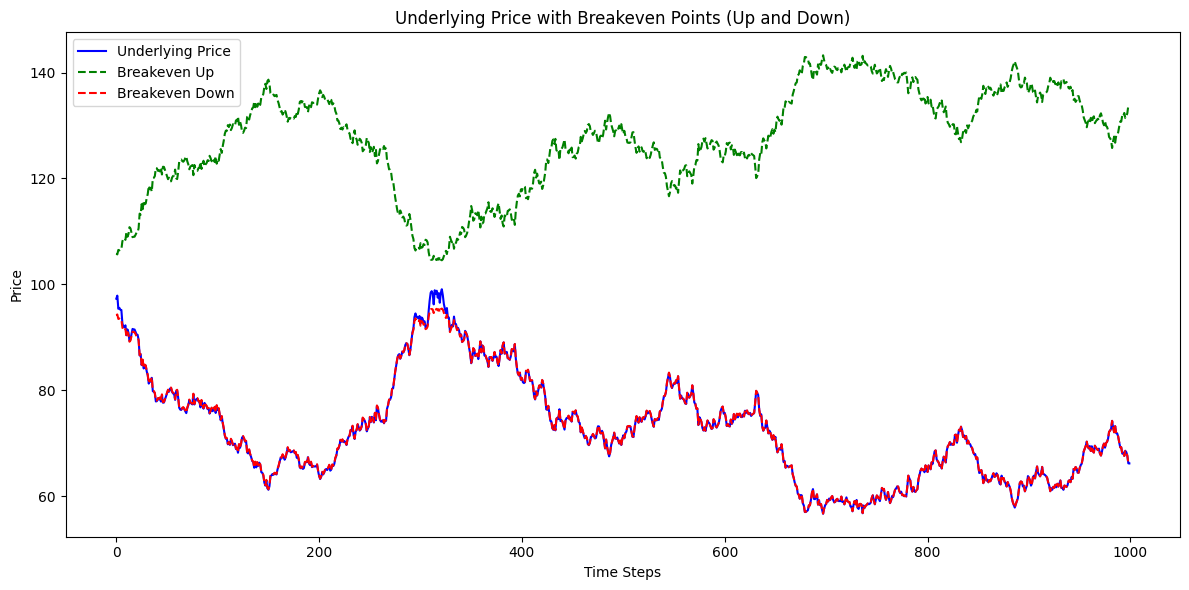

('100_Call_30DTE', '100_Put_30DTE')

In [7]:
# Define the number of contracts (for simulation purposes, we'll assume 1 contract)
num_contracts = 1

# Function to calculate option premiums (we can use a simple approximation for ATM options)
def call_premium(S, K, T, r, sigma):
    from scipy.stats import norm
    T = max(T, epsilon)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def put_premium(S, K, T, r, sigma):
    from scipy.stats import norm
    T = max(T, epsilon)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# Calculate call and put premiums at each time step
call_premiums = np.array([call_premium(S[i], K, T - t[i], r, sigma) for i in range(n_steps)])
put_premiums = np.array([put_premium(S[i], K, T - t[i], r, sigma) for i in range(n_steps)])

# Max Loss (call premium + put premium) * 100 * number of contracts
max_loss = (call_premiums + put_premiums) * 100 * num_contracts

# Breakeven points
breakeven_up = K + call_premiums + put_premiums
breakeven_down = K - call_premiums - put_premiums

# Create a DataFrame for visualization including breakeven points and max loss
df_breakeven = pd.DataFrame({
    'Underlying Price': S,
    'Call Premium': call_premiums,
    'Put Premium': put_premiums,
    'Max Loss': max_loss,
    'Breakeven Up': breakeven_up,
    'Breakeven Down': breakeven_down
})

# Display the first few rows of the DataFrame
print(df_breakeven.head())

# Plot the breakeven points and the underlying price
plt.figure(figsize=(12, 6))

plt.plot(df_breakeven['Underlying Price'], label='Underlying Price', color='blue')
plt.plot(df_breakeven['Breakeven Up'], label='Breakeven Up', color='green', linestyle='--')
plt.plot(df_breakeven['Breakeven Down'], label='Breakeven Down', color='red', linestyle='--')
plt.title('Underlying Price with Breakeven Points (Up and Down)')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()

plt.tight_layout()
plt.show()

# Save to CSV
df_breakeven.to_csv('gamma_scalping_breakeven_simulation.csv', index=False)

# Instrument names for option contracts used
call_option_name = f"{K}_Call_{T*252:.0f}DTE"
put_option_name = f"{K}_Put_{T*252:.0f}DTE"

(call_option_name, put_option_name)


   Underlying Price  Straddle Profit  Futures Profit  Total Fees  \
0         97.309143         0.000000        0.000000    0.000000   
1         97.886793       211.320701      -57.764999    0.335925   
2         95.399860       460.013981      248.693280    0.664402   
3         95.584120       441.587961      -18.426019    0.661822   
4         95.207605       479.239506       37.651545    0.667094   

   Total Profit (Strategy)  Buy and Hold PnL  
0               100.000000        100.000000  
1               253.219778        157.764999  
2               808.042859        -90.928281  
3               522.500120        -72.502261  
4               616.223957       -110.153806  


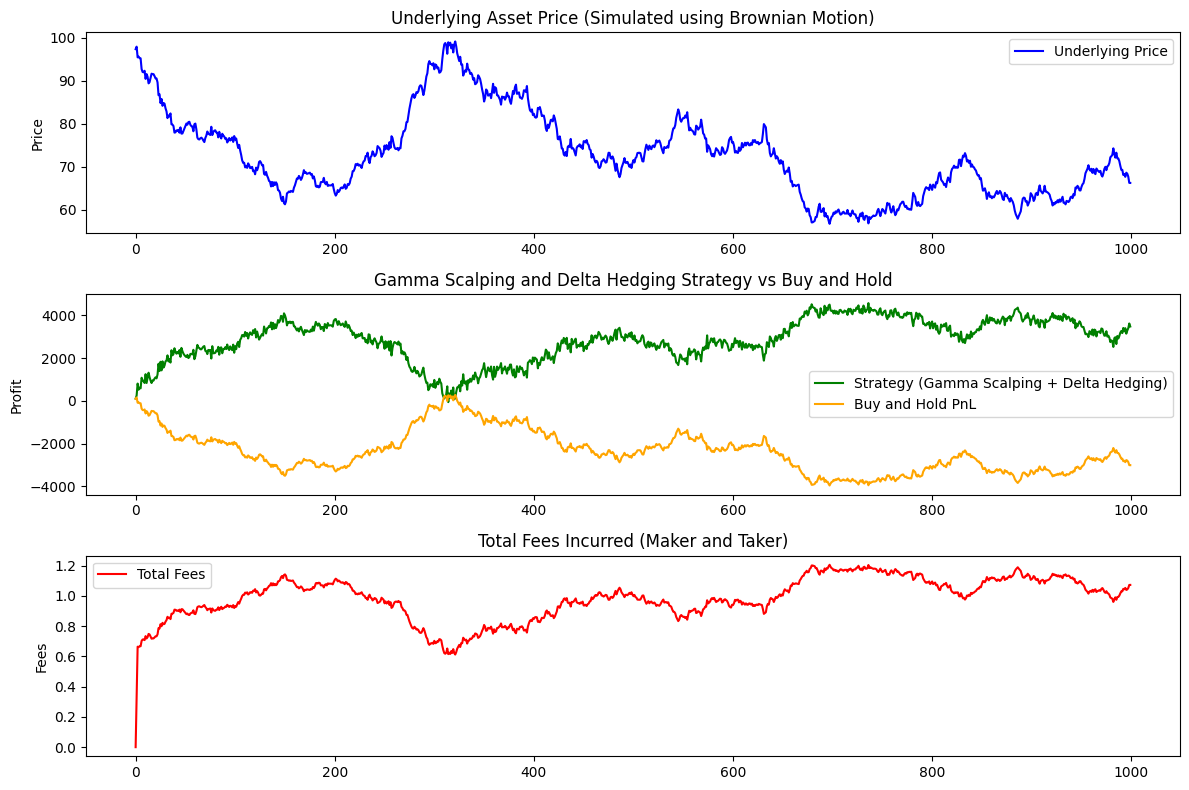

In [8]:
# Define new parameters for the updated simulation
num_contracts = 10  # buying 10 contracts for both call and put options
contract_price = 10  # each contract worth $10
starting_capital = 100  # starting capital

# Recalculate the delta hedging and gamma scalping strategy using the new settings
# Initialize variables
futures_position = 0
straddle_profit = np.zeros(n_steps)
futures_profit = np.zeros(n_steps)
total_profit = np.zeros(n_steps)
fee_costs = np.zeros(n_steps)

# Simulate Gamma Scalping and Delta Hedging with Fees and 10 Contracts
for i in range(1, n_steps):
    t_remaining = T - t[i]
    straddle_d = straddle_delta(S[i], K, t_remaining, r, sigma)
    
    # Update the futures position to delta hedge
    futures_trade_size = abs(straddle_d - futures_position)  # Size of the futures trade
    futures_position = -straddle_d
    
    # Calculate profits from options and futures position (scaled by 10 contracts)
    straddle_profit[i] = (max(S[i] - K, 0) + max(K - S[i], 0)) * num_contracts * contract_price
    futures_profit[i] = futures_position * (S[i] - S[i-1]) * num_contracts * contract_price
    
    # Trading fees
    futures_fee = futures_trade_size * S[i] * taker_fee * num_contracts
    option_fee = straddle_profit[i] * maker_fee
    
    # Track total fees
    fee_costs[i] = futures_fee + option_fee
    
    # Total profit includes fees
    total_profit[i] = straddle_profit[i] + futures_profit[i] - fee_costs[i]

# Adjust total profit with starting capital
total_profit_with_capital = total_profit + starting_capital

# Simulate the buy-and-hold strategy for comparison
buy_and_hold_pnl = (S - S[0]) * num_contracts * contract_price

# Create a DataFrame for visualization
df_benchmark = pd.DataFrame({
    'Underlying Price': S,
    'Straddle Profit': straddle_profit,
    'Futures Profit': futures_profit,
    'Total Fees': fee_costs,
    'Total Profit (Strategy)': total_profit_with_capital,
    'Buy and Hold PnL': buy_and_hold_pnl + starting_capital  # adjusted for starting capital
})

# Display the first few rows of the DataFrame
print(df_benchmark.head())

# Plot the results for benchmarking
plt.figure(figsize=(12, 8))

# Underlying Price
plt.subplot(3, 1, 1)
plt.plot(df_benchmark['Underlying Price'], label='Underlying Price', color='blue')
plt.title('Underlying Asset Price (Simulated using Brownian Motion)')
plt.ylabel('Price')
plt.legend()

# Strategy vs Buy and Hold
plt.subplot(3, 1, 2)
plt.plot(df_benchmark['Total Profit (Strategy)'], label='Strategy (Gamma Scalping + Delta Hedging)', color='green')
plt.plot(df_benchmark['Buy and Hold PnL'], label='Buy and Hold PnL', color='orange')
plt.title('Gamma Scalping and Delta Hedging Strategy vs Buy and Hold')
plt.ylabel('Profit')
plt.legend()

# Total Fees
plt.subplot(3, 1, 3)
plt.plot(df_benchmark['Total Fees'], label='Total Fees', color='red')
plt.title('Total Fees Incurred (Maker and Taker)')
plt.ylabel('Fees')
plt.legend()

plt.tight_layout()
plt.show()

# Save to CSV
df_benchmark.to_csv('gamma_scalping_benchmark_simulation.csv', index=False)


   Underlying Price  Straddle Profit (Realized)  Futures Profit (Realized)  \
0         97.309143                    0.000000                   0.000000   
1         97.886793                   76.609889                 -28.882499   
2         95.399860                  354.021429                 124.346640   
3         95.584120                  211.250060                  -9.213010   
4         95.207605                  258.111979                  18.825772   

   Total Fees  Total Profit (Strategy)  Buy and Hold PnL  
0    0.000000                 0.000000        100.000000  
1    0.167962               153.219778        128.882499  
2    0.332201               784.652747          4.535860  
3    0.330911               853.131438         13.748869  
4    0.333547              1158.105335         -5.076903  


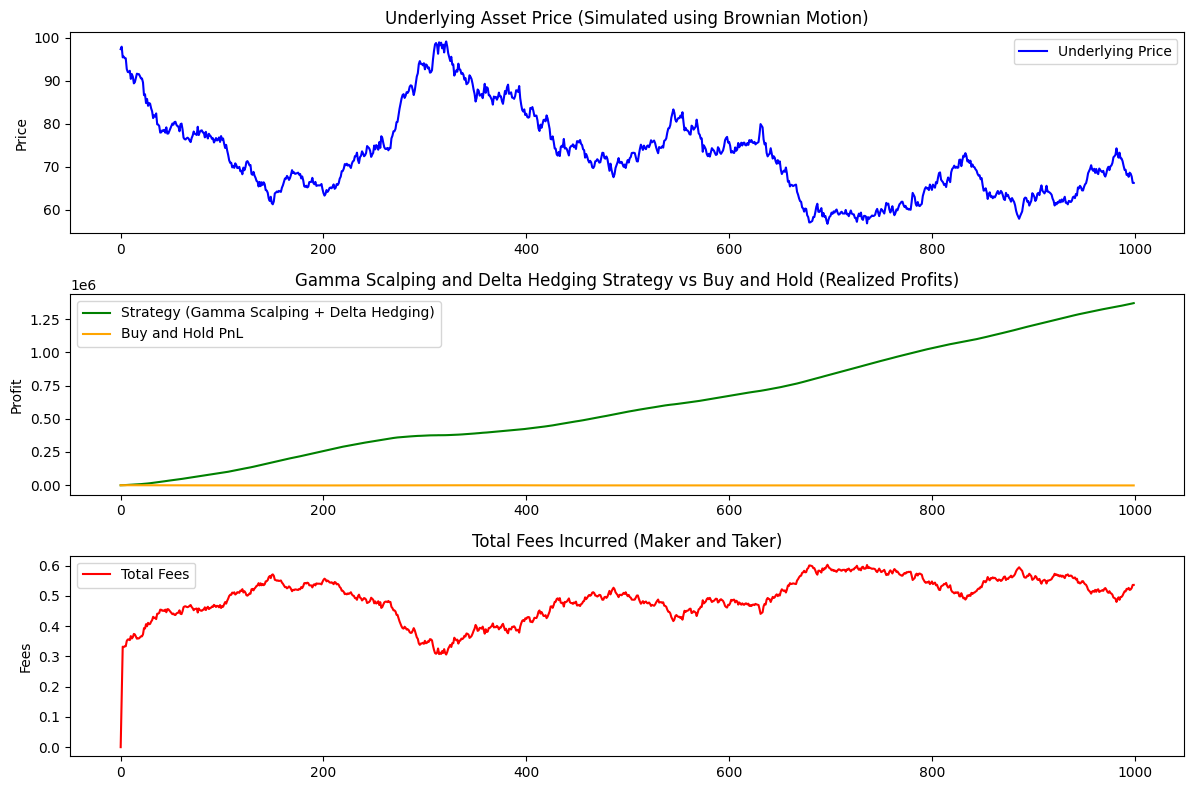

In [9]:
# Define updated starting capital and ensure enough for delta hedging
starting_capital = 100  # $100 starting capital

# Initialize variables for managing contracts and available capital
contract_price = 10  # each contract is $10
remaining_capital = starting_capital  # capital available after buying contracts

# Calculate the number of contracts we can afford
max_contracts = int(remaining_capital // (contract_price * 2))  # buy both call and put
remaining_capital -= max_contracts * contract_price * 2  # Adjust remaining capital after buying contracts

# Initialize variables for profit, fees, and capital tracking
futures_position = 0
straddle_profit = np.zeros(n_steps)
futures_profit = np.zeros(n_steps)
total_profit = np.zeros(n_steps)
fee_costs = np.zeros(n_steps)
realized_profit = np.zeros(n_steps)

# Simulate Gamma Scalping and Delta Hedging with fees, adjusting for capital
for i in range(1, n_steps):
    t_remaining = T - t[i]
    straddle_d = straddle_delta(S[i], K, t_remaining, r, sigma)
    
    # Update the futures position to delta hedge
    futures_trade_size = abs(straddle_d - futures_position)  # Size of the futures trade
    futures_position = -straddle_d
    
    # Calculate realized profits from options and futures (scaled by max_contracts)
    straddle_profit[i] = (max(S[i] - K, 0) + max(K - S[i], 0)) * max_contracts * contract_price
    realized_profit[i] += straddle_profit[i]  # Each gamma scalping iteration realizes the profit
    
    # Futures profit calculation (realized)
    futures_profit[i] = futures_position * (S[i] - S[i-1]) * max_contracts * contract_price
    realized_profit[i] += futures_profit[i]  # Realized profit from futures delta hedging
    
    # Trading fees
    futures_fee = futures_trade_size * S[i] * taker_fee * max_contracts
    option_fee = straddle_profit[i] * maker_fee
    
    # Track total fees
    fee_costs[i] = futures_fee + option_fee
    
    # Deduct fees from realized profits and remaining capital
    realized_profit[i] -= fee_costs[i]
    remaining_capital += realized_profit[i]  # Add realized profits back into available capital

    # Total profit includes realized profits and remaining capital
    total_profit[i] = realized_profit[i] + remaining_capital

# Adjust total profit with starting capital
total_profit_with_capital = total_profit

# Simulate the buy-and-hold strategy for comparison
buy_and_hold_pnl = (S - S[0]) * max_contracts * contract_price

# Create a DataFrame for visualization
df_benchmark_adjusted = pd.DataFrame({
    'Underlying Price': S,
    'Straddle Profit (Realized)': realized_profit,
    'Futures Profit (Realized)': futures_profit,
    'Total Fees': fee_costs,
    'Total Profit (Strategy)': total_profit_with_capital,
    'Buy and Hold PnL': buy_and_hold_pnl + starting_capital  # adjusted for starting capital
})

# Display the first few rows of the DataFrame
print(df_benchmark_adjusted.head())

# Plot the results for benchmarking
plt.figure(figsize=(12, 8))

# Underlying Price
plt.subplot(3, 1, 1)
plt.plot(df_benchmark_adjusted['Underlying Price'], label='Underlying Price', color='blue')
plt.title('Underlying Asset Price (Simulated using Brownian Motion)')
plt.ylabel('Price')
plt.legend()

# Strategy vs Buy and Hold
plt.subplot(3, 1, 2)
plt.plot(df_benchmark_adjusted['Total Profit (Strategy)'], label='Strategy (Gamma Scalping + Delta Hedging)', color='green')
plt.plot(df_benchmark_adjusted['Buy and Hold PnL'], label='Buy and Hold PnL', color='orange')
plt.title('Gamma Scalping and Delta Hedging Strategy vs Buy and Hold (Realized Profits)')
plt.ylabel('Profit')
plt.legend()

# Total Fees
plt.subplot(3, 1, 3)
plt.plot(df_benchmark_adjusted['Total Fees'], label='Total Fees', color='red')
plt.title('Total Fees Incurred (Maker and Taker)')
plt.ylabel('Fees')
plt.legend()

plt.tight_layout()
plt.show()

# Save to CSV
df_benchmark_adjusted.to_csv('gamma_scalping_benchmark_simulation_adjusted.csv', index=False)


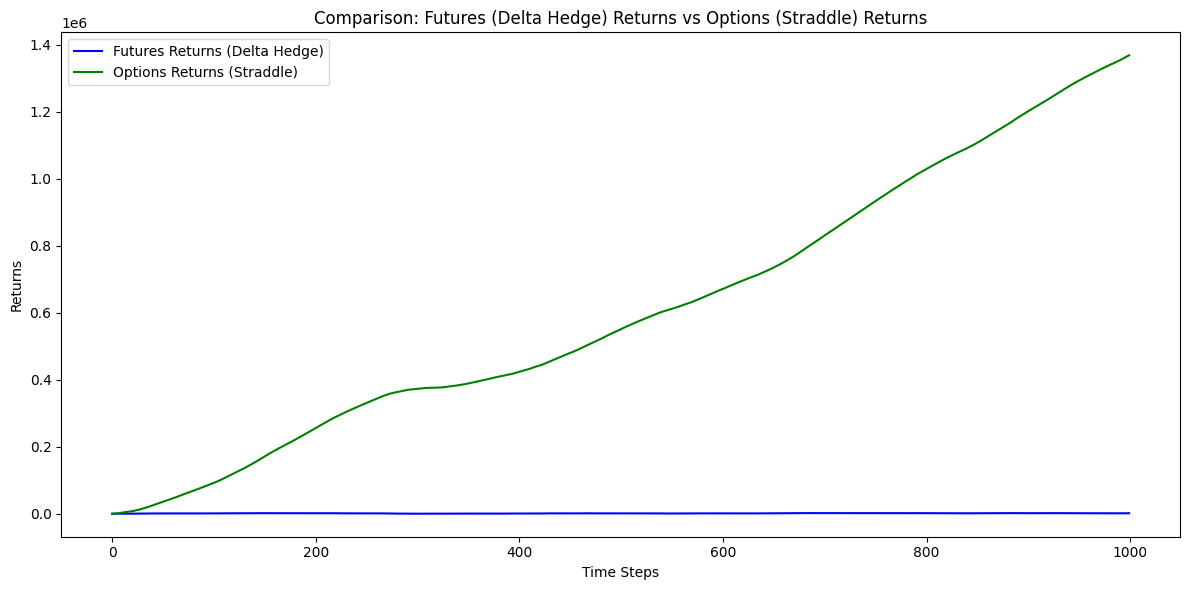

In [10]:
# Create new columns for plotting the returns of the futures position and options position
df_benchmark_adjusted['Futures Returns (Delta Hedge)'] = df_benchmark_adjusted['Futures Profit (Realized)'].cumsum()
df_benchmark_adjusted['Options Returns (Straddle)'] = df_benchmark_adjusted['Straddle Profit (Realized)'].cumsum()

# Plot the returns of futures vs options position
plt.figure(figsize=(12, 6))

plt.plot(df_benchmark_adjusted['Futures Returns (Delta Hedge)'], label='Futures Returns (Delta Hedge)', color='blue')
plt.plot(df_benchmark_adjusted['Options Returns (Straddle)'], label='Options Returns (Straddle)', color='green')
plt.title('Comparison: Futures (Delta Hedge) Returns vs Options (Straddle) Returns')
plt.xlabel('Time Steps')
plt.ylabel('Returns')
plt.legend()

plt.tight_layout()
plt.show()


In [11]:
# Calculate the total number of contracts we bought
# We initially bought as many contracts as we could afford with the given capital
total_contracts_bought = max_contracts * 2  # Call and Put options, so multiply by 2

# Calculate total realized profits
total_realized_profit = df_benchmark_adjusted['Total Profit (Strategy)'].iloc[-1] - starting_capital  # Net profit

# Calculate gross profit (total realized profit + total fees)
total_fees = df_benchmark_adjusted['Total Fees'].sum()
gross_profit = total_realized_profit + total_fees

# Display the results
print(f"Total Contracts Bought: {total_contracts_bought}")
print(f"Total Realized Profit (Net): ${total_realized_profit:.2f}")
print(f"Gross Profit: ${gross_profit:.2f}")
print(f"Total Fees: ${total_fees:.2f}")


Total Contracts Bought: 10
Total Realized Profit (Net): $1369668.59
Gross Profit: $1370159.52
Total Fees: $490.94


   Underlying Price (Low Vol)  Total Profit (Low Vol)  \
0                  101.159818                0.000000   
1                  100.722307              215.363026   
2                  100.093296              229.309769   
3                  100.851961              202.203091   
4                  100.637741              282.428897   

   Total Profit (Medium Vol)  Total Profit (High Vol)  
0                   0.000000                 0.000000  
1                 179.350831              1087.156637  
2                 194.855929              1759.030912  
3                 381.997763              2223.690384  
4                 276.434471              2735.441401  


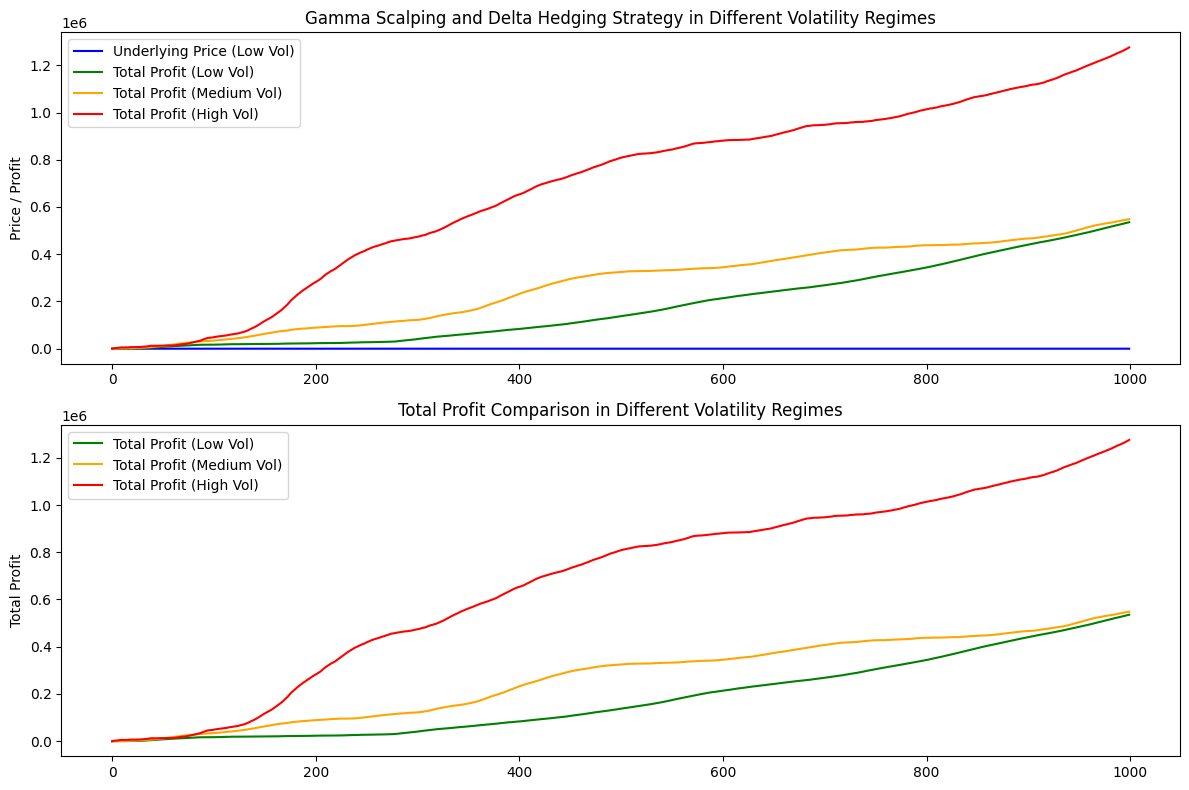

In [12]:
# Define volatility regimes
low_volatility = 0.1
medium_volatility = 0.2  # Default, already used in previous simulations
high_volatility = 0.4

# Function to run the gamma scalping simulation under different volatility regimes
def gamma_scalping_simulation(volatility):
    # Simulate underlying price using Geometric Brownian Motion with adjusted volatility
    S = S0 * np.exp((mu - 0.5 * volatility ** 2) * t + volatility * np.sqrt(dt) * np.random.randn(n_steps).cumsum())
    
    # Initialize variables for managing profits, fees, and capital tracking
    futures_position = 0
    straddle_profit = np.zeros(n_steps)
    futures_profit = np.zeros(n_steps)
    total_profit = np.zeros(n_steps)
    fee_costs = np.zeros(n_steps)
    realized_profit = np.zeros(n_steps)
    remaining_capital = starting_capital

    # Simulate gamma scalping with futures delta hedging for the given volatility
    for i in range(1, n_steps):
        t_remaining = T - t[i]
        straddle_d = straddle_delta(S[i], K, t_remaining, r, volatility)
        
        # Update the futures position to delta hedge
        futures_position = -straddle_d
        
        # Calculate realized profits from options and futures (scaled by max_contracts)
        straddle_profit[i] = (max(S[i] - K, 0) + max(K - S[i], 0)) * max_contracts * contract_price
        realized_profit[i] += straddle_profit[i]  # Realized profit from gamma scalping
        
        # Futures profit calculation (realized)
        futures_profit[i] = futures_position * (S[i] - S[i-1]) * max_contracts * contract_price
        realized_profit[i] += futures_profit[i]  # Realized profit from delta hedging
        
        # Trading fees
        futures_fee = futures_trade_size * S[i] * taker_fee * max_contracts
        option_fee = straddle_profit[i] * maker_fee
        
        # Track total fees
        fee_costs[i] = futures_fee + option_fee
        
        # Deduct fees from realized profits
        realized_profit[i] -= fee_costs[i]
        remaining_capital += realized_profit[i]  # Add realized profits back into available capital

        # Total profit includes realized profits and remaining capital
        total_profit[i] = realized_profit[i] + remaining_capital

    return S, total_profit, fee_costs

# Run simulations for each volatility regime
S_low, total_profit_low, fees_low = gamma_scalping_simulation(low_volatility)
S_medium, total_profit_medium, fees_medium = gamma_scalping_simulation(medium_volatility)
S_high, total_profit_high, fees_high = gamma_scalping_simulation(high_volatility)

# Create a DataFrame for visualization
df_volatility_comparison = pd.DataFrame({
    'Underlying Price (Low Vol)': S_low,
    'Total Profit (Low Vol)': total_profit_low,
    'Total Profit (Medium Vol)': total_profit_medium,
    'Total Profit (High Vol)': total_profit_high
})

# Display the first few rows of the DataFrame
print(df_volatility_comparison.head())

# Plot the results for different volatility regimes
plt.figure(figsize=(12, 8))

# Underlying Price and Profits in Different Volatility Regimes
plt.subplot(2, 1, 1)
plt.plot(df_volatility_comparison['Underlying Price (Low Vol)'], label='Underlying Price (Low Vol)', color='blue')
plt.plot(df_volatility_comparison['Total Profit (Low Vol)'], label='Total Profit (Low Vol)', color='green')
plt.plot(df_volatility_comparison['Total Profit (Medium Vol)'], label='Total Profit (Medium Vol)', color='orange')
plt.plot(df_volatility_comparison['Total Profit (High Vol)'], label='Total Profit (High Vol)', color='red')
plt.title('Gamma Scalping and Delta Hedging Strategy in Different Volatility Regimes')
plt.ylabel('Price / Profit')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(df_volatility_comparison['Total Profit (Low Vol)'], label='Total Profit (Low Vol)', color='green')
plt.plot(df_volatility_comparison['Total Profit (Medium Vol)'], label='Total Profit (Medium Vol)', color='orange')
plt.plot(df_volatility_comparison['Total Profit (High Vol)'], label='Total Profit (High Vol)', color='red')
plt.title('Total Profit Comparison in Different Volatility Regimes')
plt.ylabel('Total Profit')
plt.legend()

plt.tight_layout()
plt.show()

# Save to CSV
df_volatility_comparison.to_csv('gamma_scalping_volatility_comparison.csv', index=False)


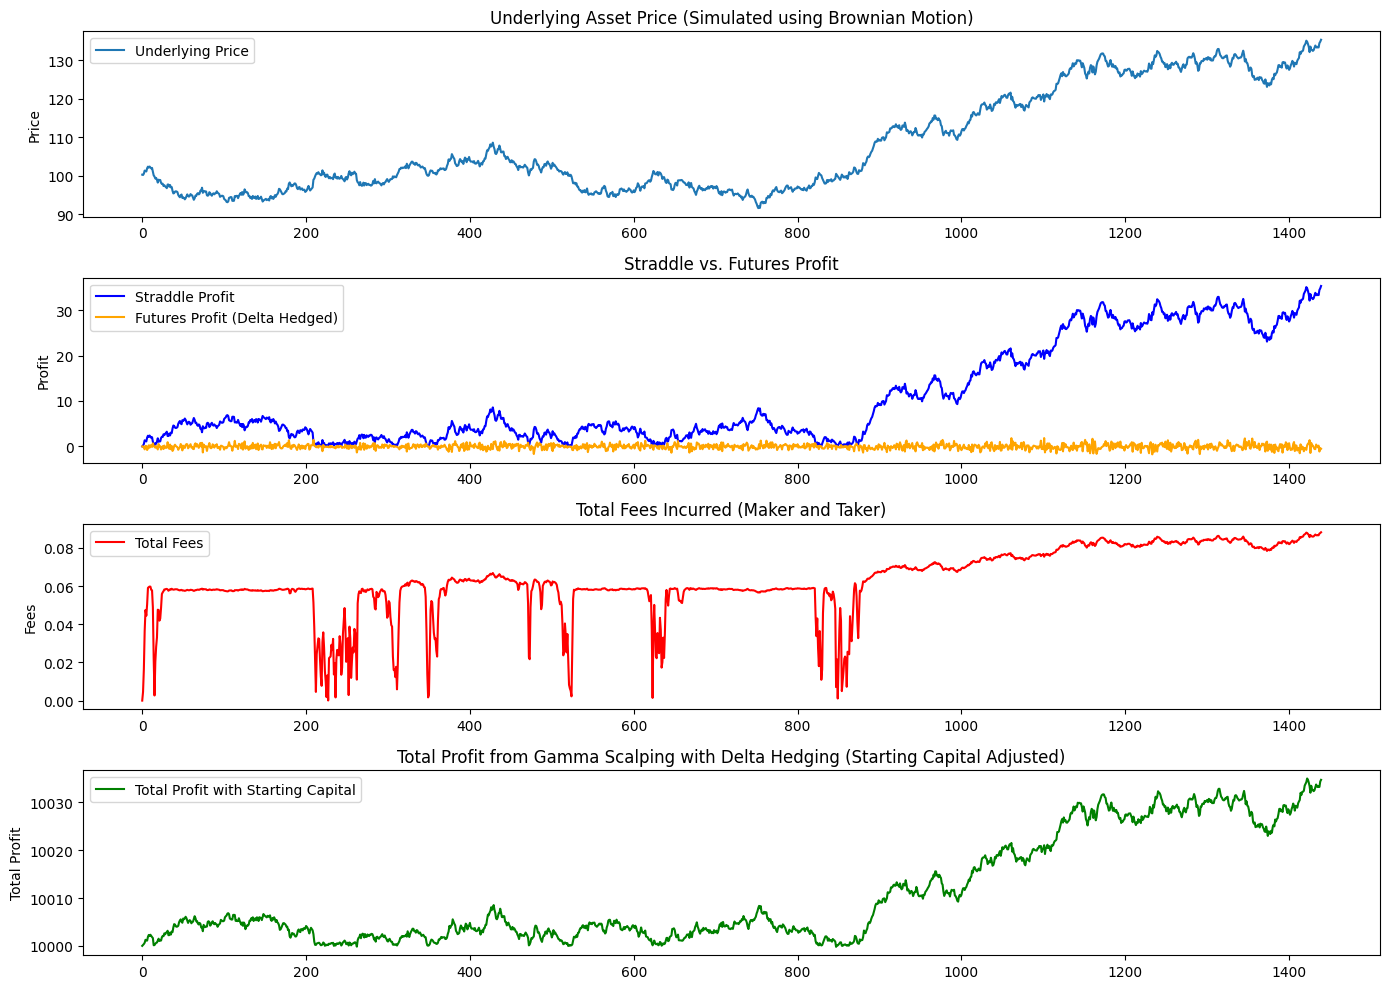

In [18]:
# Adding a small epsilon to avoid division by zero in the Black-Scholes Greeks calculation
epsilon = 1e-6  # Small constant to avoid division by zero

# Updated Black-Scholes Greeks calculation
def straddle_delta(S, K, T, r, sigma):
    """Calculate the straddle delta as a combination of call and put deltas."""
    T = max(T, epsilon)  # Ensure time-to-expiration is never zero
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    delta_call = norm.cdf(d1)
    delta_put = norm.cdf(d1) - 1
    return delta_call - abs(delta_put)

# Parameters for the GBM process
S0 = 100  # Initial price of the underlying asset
K = 100  # Strike price (ATM)
T = 1 / 365  # Time to expiration (1 day)
mu = 0.0001  # Drift
sigma = 0.2  # Volatility
r = 0.01  # Risk-free rate
dt = 1 / (24 * 60)  # 1 minute steps (24 hours * 60 minutes)
n_steps = int(1 / dt)  # Number of steps for 1 day simulation

# Simulate underlying price using GBM
np.random.seed(42)  # Set seed for reproducibility
t = np.linspace(0, T, n_steps)
S = S0 * np.exp((mu - 0.5 * sigma ** 2) * t + sigma * np.sqrt(dt) * np.random.randn(n_steps).cumsum())

# Trading fees
maker_fee = 0.020 / 100  # 0.020% maker fee
taker_fee = 0.030 / 100  # 0.030% taker fee

# Initialize variables
futures_position = 0
straddle_profit = np.zeros(n_steps)
futures_profit = np.zeros(n_steps)
total_profit = np.zeros(n_steps)
fee_costs = np.zeros(n_steps)
starting_capital = 10000

# Simulate Gamma Scalping and Delta Hedging with Fees
for i in range(1, n_steps):
    t_remaining = T - t[i]
    straddle_d = straddle_delta(S[i], K, t_remaining, r, sigma)
    
    # Update the futures position to delta hedge
    futures_trade_size = abs(straddle_d - futures_position)  # Size of the futures trade
    futures_position = -straddle_d
    
    # Calculate profits from options and futures position
    straddle_profit[i] = max(S[i] - K, 0) + max(K - S[i], 0)
    futures_profit[i] = futures_position * (S[i] - S[i-1])
    
    # Trading fees
    futures_fee = futures_trade_size * S[i] * taker_fee  # Fee for delta hedging (taker)
    option_fee = straddle_profit[i] * maker_fee  # Fee for option transactions (maker)
    
    # Track total fees
    fee_costs[i] = futures_fee + option_fee
    
    # Total profit includes fees
    total_profit[i] = straddle_profit[i] + futures_profit[i] - fee_costs[i]

# Adjust total profit with starting capital
total_profit_with_capital = total_profit + starting_capital

# Create a DataFrame for visualization including fees
df_with_fees = pd.DataFrame({
    'Underlying Price': S,
    'Straddle Profit': straddle_profit,
    'Futures Profit': futures_profit,
    'Total Fees': fee_costs,
    'Total Profit': total_profit,
    'Total Profit with Starting Capital': total_profit_with_capital
})

# Display the DataFrame as output
df_with_fees.head()

# Plot the results
plt.figure(figsize=(14, 10))

# Underlying Price
plt.subplot(4, 1, 1)
plt.plot(df_with_fees['Underlying Price'], label='Underlying Price')
plt.title('Underlying Asset Price (Simulated using Brownian Motion)')
plt.ylabel('Price')
plt.legend()

# Straddle and Futures Profit
plt.subplot(4, 1, 2)
plt.plot(df_with_fees['Straddle Profit'], label='Straddle Profit', color='blue')
plt.plot(df_with_fees['Futures Profit'], label='Futures Profit (Delta Hedged)', color='orange')
plt.title('Straddle vs. Futures Profit')
plt.ylabel('Profit')
plt.legend()

# Total Fees
plt.subplot(4, 1, 3)
plt.plot(df_with_fees['Total Fees'], label='Total Fees', color='red')
plt.title('Total Fees Incurred (Maker and Taker)')
plt.ylabel('Fees')
plt.legend()

# Total Profit with Starting Capital
plt.subplot(4, 1, 4)
plt.plot(df_with_fees['Total Profit with Starting Capital'], label='Total Profit with Starting Capital', color='green')
plt.title('Total Profit from Gamma Scalping with Delta Hedging (Starting Capital Adjusted)')
plt.ylabel('Total Profit')
plt.legend()

plt.tight_layout()
plt.show()

# Save the results to a CSV file
df_with_fees.to_csv('gamma_scalping_delta_hedging_simulation_with_fees_fixed.csv', index=False)


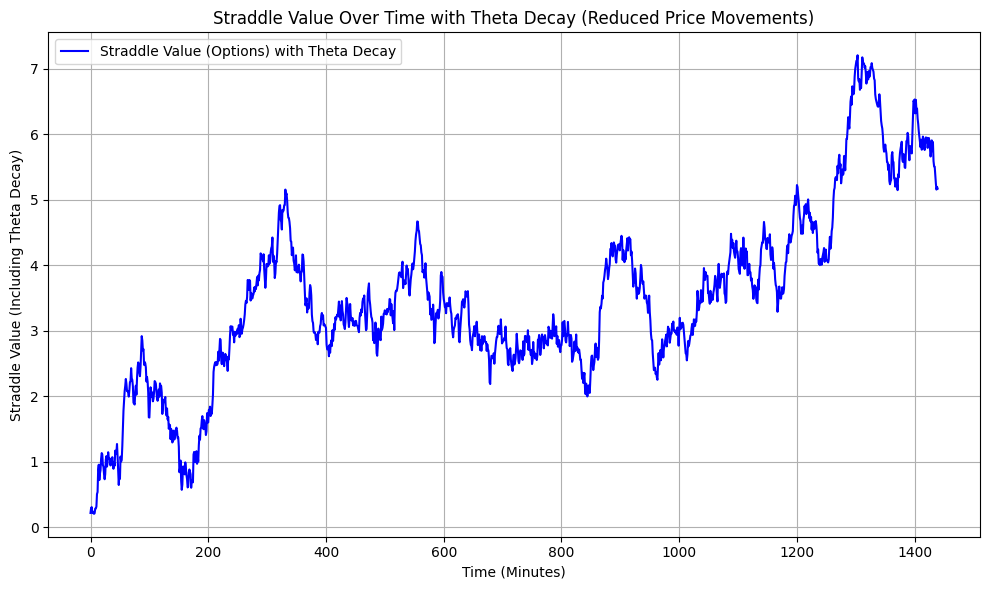

In [11]:
# Adjust the simulation to reduce price movement and better observe theta decay effects

# New GBM with smaller fluctuations to show theta decay more clearly
mu = 0  # No drift (stable price environment)
sigma = 0.05  # Reduced volatility

# Simulate underlying price with smaller movements
S = S0 * np.exp((mu - 0.5 * sigma ** 2) * t + sigma * np.sqrt(dt) * np.random.randn(n_steps).cumsum())

# Recalculate the straddle value with theta decay for this stable environment
straddle_value_with_theta = np.zeros(n_steps)

for i in range(n_steps):
    t_remaining = T - t[i]
    
    # Calculate Black-Scholes prices for both call and put options
    call_price = black_scholes_price(S[i], K, t_remaining, r, sigma, option_type="call")
    put_price = black_scholes_price(S[i], K, t_remaining, r, sigma, option_type="put")
    
    # Straddle value is the sum of the call and put option prices
    straddle_value_with_theta[i] = call_price + put_price

# Plot the updated straddle value over time with reduced price fluctuations
plt.figure(figsize=(10, 6))

# Plot the value of the straddle over time with theta decay
plt.plot(straddle_value_with_theta, label='Straddle Value (Options) with Theta Decay', color='blue')
plt.title('Straddle Value Over Time with Theta Decay (Reduced Price Movements)')
plt.xlabel('Time (Minutes)')
plt.ylabel('Straddle Value (Including Theta Decay)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


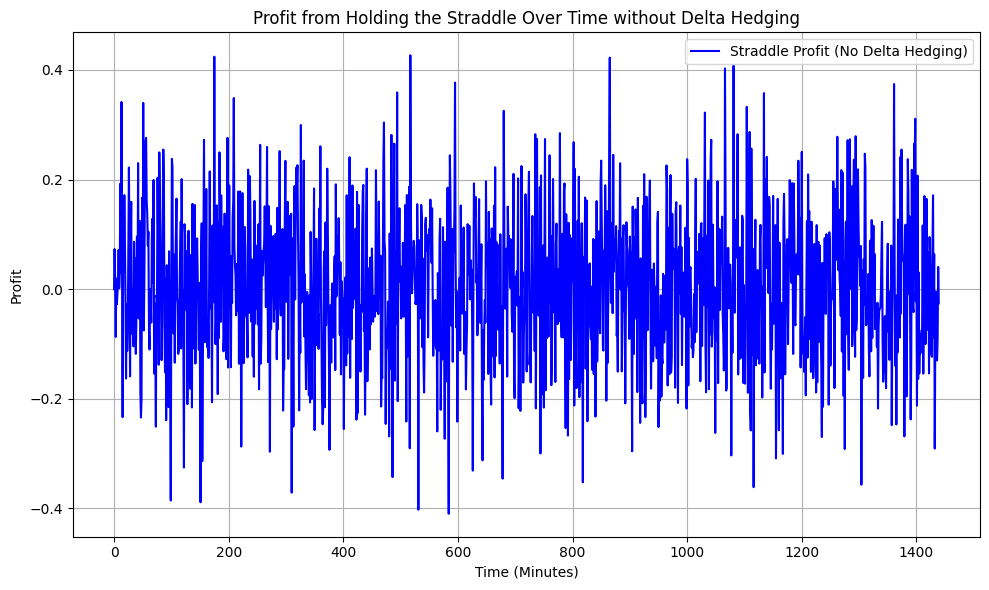

In [13]:
# Calculate the profit from holding the straddle without delta hedging
straddle_profit_no_delta_hedge = np.zeros(n_steps)

# Profit is the change in the straddle value from one step to the next
for i in range(1, n_steps):
    straddle_profit_no_delta_hedge[i] = straddle_value_no_delta_hedge[i] - straddle_value_no_delta_hedge[i-1]

# Plot the profit over time from holding the straddle without delta hedging
plt.figure(figsize=(10, 6))

# Plot the straddle profit over time (no delta hedging)
plt.plot(straddle_profit_no_delta_hedge, label='Straddle Profit (No Delta Hedging)', color='blue')
plt.title('Profit from Holding the Straddle Over Time without Delta Hedging')
plt.xlabel('Time (Minutes)')
plt.ylabel('Profit')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


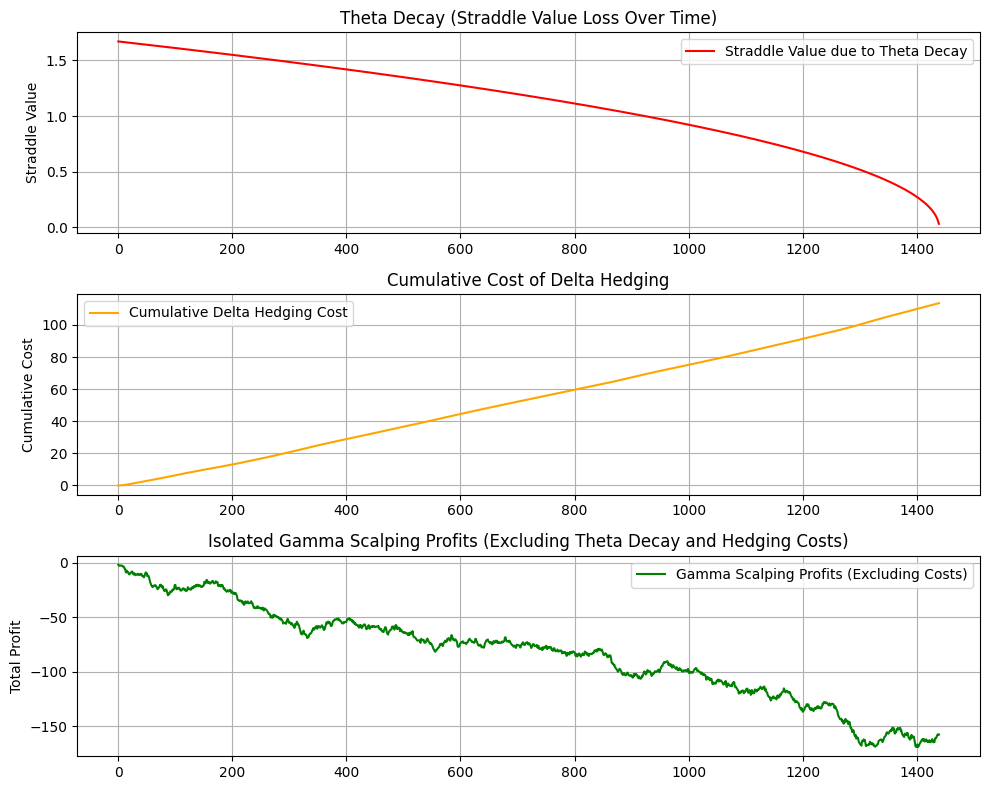

In [20]:
# Step 1: Isolate the effect of Theta Decay (Time Decay)

# Recalculate the straddle value based only on theta decay (no price movement)
straddle_value_theta_decay = np.zeros(n_steps)

# Assume the underlying price remains constant at its initial value
S_constant = np.full(n_steps, S0)

# Calculate the straddle value over time due to theta decay
for i in range(n_steps):
    t_remaining = T - t[i]
    
    # Calculate the Black-Scholes prices for both the call and put options
    call_price_theta = black_scholes_price(S_constant[i], K, t_remaining, r, sigma_high_vol, option_type="call")
    put_price_theta = black_scholes_price(S_constant[i], K, t_remaining, r, sigma_high_vol, option_type="put")
    
    # Straddle value is the sum of the call and put option prices
    straddle_value_theta_decay[i] = call_price_theta + put_price_theta

# Step 2: Calculate the cumulative cost of Delta Hedging (futures trades)

cumulative_hedging_cost = np.zeros(n_steps)

# Initialize for delta hedging (cumulative cost calculation)
futures_position = 0

for i in range(1, n_steps):
    t_remaining = T - t[i]
    
    # Calculate the delta of the straddle at the current step
    straddle_d = straddle_delta(S_high_vol[i], K, t_remaining, r, sigma_high_vol)
    
    # Calculate the size of the futures trade required to hedge delta
    futures_trade_size = abs(straddle_d - futures_position)
    futures_position = -straddle_d  # Adjust to delta-neutral
    
    # Add the cost of the futures trade (for simplicity, assume a small fee or slippage in each trade)
    cumulative_hedging_cost[i] = cumulative_hedging_cost[i-1] + futures_trade_size * S_high_vol[i] * taker_fee

# Step 3: Calculate the potential profits from Gamma Scalping (excluding theta decay and hedging costs)

gamma_scalping_profits = total_profit_delta_hedge_high_vol - straddle_value_theta_decay - cumulative_hedging_cost

# Plot the individual components for analysis
plt.figure(figsize=(10, 8))

# Theta Decay (Straddle value decay over time)
plt.subplot(3, 1, 1)
plt.plot(straddle_value_theta_decay, label='Straddle Value due to Theta Decay', color='red')
plt.title('Theta Decay (Straddle Value Loss Over Time)')
plt.ylabel('Straddle Value')
plt.legend()
plt.grid(True)

# Cumulative Delta Hedging Cost
plt.subplot(3, 1, 2)
plt.plot(cumulative_hedging_cost, label='Cumulative Delta Hedging Cost', color='orange')
plt.title('Cumulative Cost of Delta Hedging')
plt.ylabel('Cumulative Cost')
plt.legend()
plt.grid(True)

# Gamma Scalping Profits (Isolated from Theta Decay and Hedging Costs)
plt.subplot(3, 1, 3)
plt.plot(gamma_scalping_profits, label='Gamma Scalping Profits (Excluding Costs)', color='green')
plt.title('Isolated Gamma Scalping Profits (Excluding Theta Decay and Hedging Costs)')
plt.ylabel('Total Profit')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
